In [ ]:
import zipfile
from google.colab import files
import os

print("Please upload your zipped image dataset folder (e.g., 'images.zip').")

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  # Assuming the uploaded file is a zip archive
  try:
    with zipfile.ZipFile(fn, 'r') as zip_ref:
      zip_ref.extractall(os.path.join(os.getcwd(), 'dataset')) # Extract to a 'dataset' folder
    print(f'Successfully extracted "{fn}" to the "dataset" folder.')
  except zipfile.BadZipFile:
    print(f'Error: "{fn}" is not a valid zip file. Please upload a zip archive.')
  except Exception as e:
    print(f'An unexpected error occurred: {e}')

# List the contents of the created 'dataset' folder to confirm
if os.path.exists('dataset'):
  print('\nContents of the \'dataset\' folder:')
  for root, dirs, files in os.walk('dataset'):
    level = root.replace('dataset', '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
      print(f'{subindent}{f}')
else:
  print('\nNo \'dataset\' folder was created.')

Please upload your zipped image dataset folder (e.g., 'images.zip').


Saving Flower_Dataset.zip to Flower_Dataset.zip
User uploaded file "Flower_Dataset.zip" with length 215160703 bytes
Successfully extracted "Flower_Dataset.zip" to the "dataset" folder.

Contents of the 'dataset' folder:
dataset/
    Flower_Dataset/
        test/
            Image_611.jpg
            Image_223.jpg
            Image_354.jpg
            Image_763.jpg
            Image_692.jpg
            Image_8.jpg
            Image_53.jpg
            Image_618.jpg
            Image_502.jpg
            Image_590.jpg
            Image_664.jpg
            Image_22.jpg
            Image_659.jpg
            Image_480.jpg
            Image_248.jpg
            Image_408.jpg
            Image_350.jpg
            Image_613.jpg
            Image_429.jpg
            Image_145.jpg
            Image_81.jpg
            Image_67.jpg
            Image_639.jpg
            Image_2.jpg
            Image_454.jpg
            Image_789.jpg
            Image_146.jpg
            Image_784.jpg
            Image

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os

# Define dataset path
dataset_base_path = 'dataset/Flower_Dataset'

# Define image dimensions and batch size
img_height = 224 # VGG16 expects 224x224 input
img_width = 224
batch_size = 32

In [ ]:
print('Loading combined dataset from train directory for splitting...')
combined_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_base_path, 'train'),
    labels='inferred',
    label_mode='categorical',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    seed=123 # Important for reproducible splits
)

# Get the number of batches in the combined dataset
# Using `cardinality().numpy()` might return -1 for infinite datasets, so a fallback is added.
num_batches = combined_ds.cardinality().numpy()
if num_batches == tf.data.UNKNOWN_CARDINALITY:
    print("Warning: Dataset cardinality unknown. Iterating to count batches. This might take a moment.")
    num_batches = 0
    for _ in combined_ds:
        num_batches += 1

# Define split percentages for batches (e.g., 70% train, 15% val, 15% test)
train_split_ratio = 0.7
val_split_ratio = 0.15

train_batches = int(train_split_ratio * num_batches)
val_batches = int(val_split_ratio * num_batches)
test_batches = num_batches - train_batches - val_batches # Remaining batches for test

print(f"Total batches from '{os.path.join(dataset_base_path, 'train')}': {num_batches}")
print(f"Training batches: {train_batches}")
print(f"Validation batches: {val_batches}")
print(f"Test batches: {test_batches}")

# Create the final datasets using take() and skip()
train_ds = combined_ds.take(train_batches)
val_test_ds_temp = combined_ds.skip(train_batches)
val_ds = val_test_ds_temp.take(val_batches)
test_ds = val_test_ds_temp.skip(test_batches)

# Get class names and number of classes from the combined dataset
class_names = combined_ds.class_names
num_classes = len(class_names)
print(f"Found {num_classes} classes: {class_names}")

Loading combined dataset from train directory for splitting...
Found 2746 files belonging to 5 classes.
Total batches from 'dataset/Flower_Dataset/train': 86
Training batches: 60
Validation batches: 12
Test batches: 14
Found 5 classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


In [ ]:
# Load the pre-trained VGG16 model without the top classification layer
base_model = keras.applications.VGG16(
    weights='imagenet',  # Use pre-trained ImageNet weights
    include_top=False,   # Do not include the top (classification) layers
    input_shape=(img_height, img_width, 3) # Specify input shape
)

# Freeze the base model to prevent its weights from being updated during the first training phase
base_model.trainable = False

# Create a new model on top of the pre-trained base
model = keras.Sequential([
    # Preprocessing layer to normalize pixel values to [0, 1] (VGG expects this)
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # Add dropout for regularization
    layers.Dense(num_classes, activation='softmax') # Output layer for multi-class classification
])

# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,757 (80.64 MB)

 Trainable params: 6,424,069 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
epochs = 20  # You can adjust the number of epochs
history = model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds
)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1418s 24s/step - accuracy: 0.5453 - loss: 1.5482 - val_accuracy: 0.7760 - val_loss: 0.7499
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1370s 23s/step - accuracy: 0.7229 - loss: 0.7427 - val_accuracy: 0.8177 - val_loss: 0.5585
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1374s 23s/step - accuracy: 0.7766 - loss: 0.6022 - val_accuracy: 0.8333 - val_loss: 0.5272
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1367s 23s/step - accuracy: 0.8177 - loss: 0.4807 - val_accuracy: 0.8516 - val_loss: 0.4221
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1395s 23s/step - accuracy: 0.8354 - loss: 0.4368 - val_accuracy: 0.8672 - val_loss: 0.3719
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1399s 23s/step - accuracy: 0.8682 - loss: 0.3584 - val_accuracy: 0.8854 - val_loss: 0.3543
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1354s 23s/step - accuracy: 0.8891 - loss: 0.3101 - val_accuracy: 0.8672 - val_loss: 0.3987
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1358s 23s/step - accuracy: 0.8849 - loss: 0.3120 - val_accu

In [ ]:
loss, accuracy = model.evaluate(test_ds)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 227s 18s/step - accuracy: 0.8333 - loss: 0.5636

Test Loss: 0.5636
Test Accuracy: 83.33%


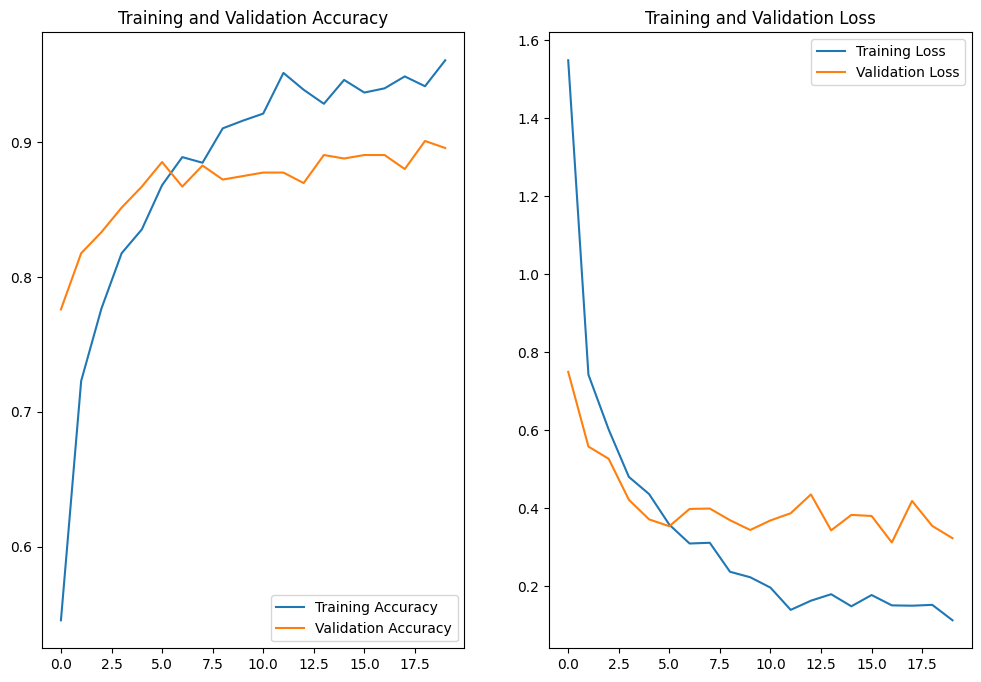

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()